# Crime in Vancouver — Data Cleaning & Exploratory Analysis

The purpose of this notebook  is to understand the Vancouver Crime dataset, identify important patterns in the data, and prepare a clean and reliable dataset for further Data Visualization.

The main goals are:

- Understand the structure and characteristics of the dataset.
- Identify and handle missing or unnecessary data.
- Clean and prepare the dataset for analysis.
- Explore crime patterns by type, time, year, and neighbourhood.
- Prepare the cleaned dataset for interactive visualizations in **Tableau** or **Power BI**.
- Create a professional **PDF report** containing important visualizations and findings.


In [59]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from datetime import datetime


In [60]:
path = kagglehub.dataset_download("wosaku/crime-in-vancouver")

print("dataset location: ", path)

dataset location:  /kaggle/input/datasets/wosaku/crime-in-vancouver


In [61]:
# Show downloaded files
for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))


/kaggle/input/datasets/wosaku/crime-in-vancouver/crime.csv
/kaggle/input/datasets/wosaku/crime-in-vancouver/googletrend.csv


In [62]:
df = pd.read_csv("/kaggle/input/datasets/wosaku/crime-in-vancouver/crime.csv")

In [63]:
df.head()

,TYPE,YEAR,MONTH,DAY,HOUR,MINUTE,HUNDRED_BLOCK,NEIGHBOURHOOD,X,Y,Latitude,Longitude
0,Other Theft,2003,5,12,16.0,15.0,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763
1,Other Theft,2003,5,7,15.0,20.0,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763
2,Other Theft,2003,4,23,16.0,40.0,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763
3,Other Theft,2003,4,20,11.0,15.0,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763
4,Other Theft,2003,4,12,17.0,45.0,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 530652 entries, 0 to 530651
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TYPE           530652 non-null  object 
 1   YEAR           530652 non-null  int64  
 2   MONTH          530652 non-null  int64  
 3   DAY            530652 non-null  int64  
 4   HOUR           476290 non-null  float64
 5   MINUTE         476290 non-null  float64
 6   HUNDRED_BLOCK  530639 non-null  object 
 7   NEIGHBOURHOOD  474028 non-null  object 
 8   X              530652 non-null  float64
 9   Y              530652 non-null  float64
 10  Latitude       530652 non-null  float64
 11  Longitude      530652 non-null  float64
dtypes: float64(6), int64(3), object(3)
memory usage: 48.6+ MB


In [65]:
df.columns = df.columns.str.lower()

In [66]:
df.isnull().sum()

type                 0
year                 0
month                0
day                  0
hour             54362
minute           54362
hundred_block       13
neighbourhood    56624
x                    0
y                    0
latitude             0
longitude            0
dtype: int64

In [67]:
df = df.drop(columns=['minute', 'hundred_block'])

In [68]:
df['neighbourhood'] = df['neighbourhood'].fillna('Unknown')

In [69]:
df['neighbourhood'].value_counts()

neighbourhood
Central Business District    110947
Unknown                       56624
West End                      41352
Fairview                      32161
Mount Pleasant                30536
Grandview-Woodland            27180
Renfrew-Collingwood           26761
Kitsilano                     26699
Kensington-Cedar Cottage      24941
Strathcona                    20919
Hastings-Sunrise              18126
Sunset                        17396
Marpole                       13083
Riley Park                    12521
Victoria-Fraserview           10819
Killarney                     10475
Oakridge                       8037
Dunbar-Southlands              7746
Kerrisdale                     7447
Arbutus Ridge                  6066
West Point Grey                5871
Shaughnessy                    5426
South Cambie                   5212
Stanley Park                   3775
Musqueam                        532
Name: count, dtype: int64

In [70]:
df['hour_viz'] = df['hour'].astype('Int64').astype('object').fillna('Unknown')

In [71]:
df['time_period'] = df['hour'].apply(
    lambda x: 'Unknown' if pd.isna(x)
    else 'Night' if x < 6
    else 'Morning' if x < 12
    else 'Afternoon' if x < 18
    else 'Evening'
)

In [72]:
df['time_period'].value_counts()

time_period
Evening      174033
Afternoon    144532
Morning       83359
Night         74366
Unknown       54362
Name: count, dtype: int64

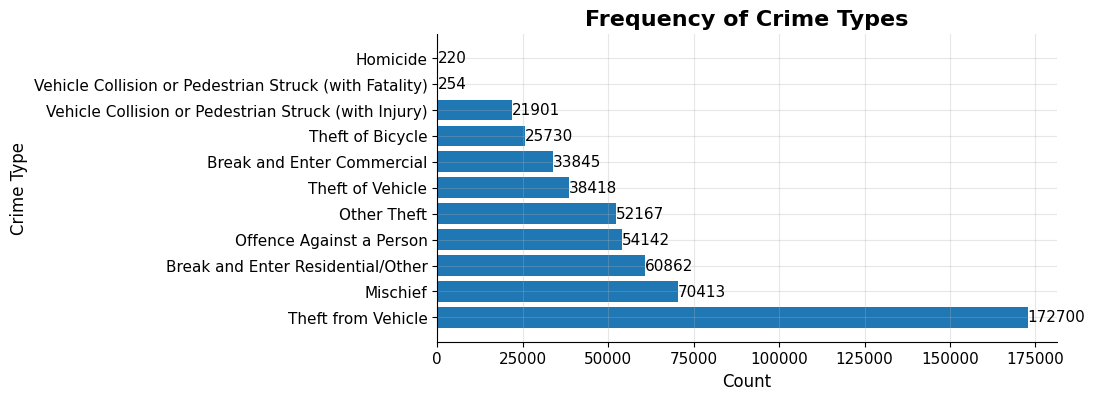

In [73]:
counts = df['type'].value_counts()

plt.figure(figsize=(8, 4))
bars = plt.barh(counts.index, counts)

for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             int(bar.get_width()), va='center')

plt.xlabel('Count')
plt.ylabel('Crime Type')
plt.title('Frequency of Crime Types')
plt.show()

In [74]:
df['type'] = df['type'].replace({
   'Vehicle Collision or Pedestrian Struck (with Injury)': 'Collision',
    'Vehicle Collision or Pedestrian Struck (with Fatality)': 'Collision'
})

df['type'] = df['type'].replace({
    'Break and Enter Residential/Other': 'Break-in',
    'Break and Enter Commercial': 'Break-in'
})

df['type'] = df['type'].replace({
'Offence Against a Person': 'Offence',
})

df['type'].value_counts()

type
Theft from Vehicle    172700
Break-in               94707
Mischief               70413
Offence                54142
Other Theft            52167
Theft of Vehicle       38418
Theft of Bicycle       25730
Collision              22155
Homicide                 220
Name: count, dtype: int64

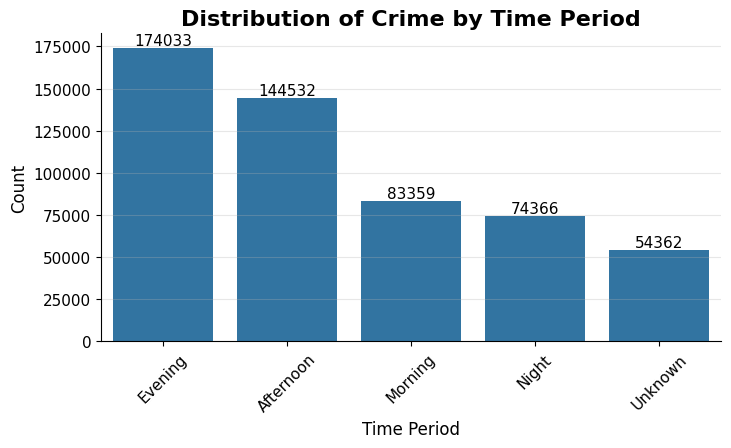

In [75]:
value_counts = df['time_period'].value_counts()    

plt.figure(figsize=(8,4))
sns.barplot(x=value_counts.index, y=value_counts)

for i, v in enumerate(value_counts):
    plt.text(i, v, str(v), ha='center', va='bottom')


plt.xlabel('Time Period')
plt.ylabel('Count')
plt.title('Distribution of Crime by Time Period')
plt.xticks(rotation=45)

sns.despine()

plt.show()

## Export Cleaned Dataset

In [76]:
os.makedirs("cleaned_data", exist_ok=True)

df.to_csv("cleaned_data/vancouver_crime_cleaned.csv", index=False)

## PDF Visualization Report

In [77]:

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

BAR_COLOR = "#3d247b"
LINE_COLOR = "#f09e69"
PALETTE = [
    "#dea53d",
    "#77467c",
    "#3d247b",
    "#f09e69",
    "#e4bbeb",
    "#ffa800",
    "#9C6644",
    "#6C7A89"
]

os.makedirs("pdf", exist_ok=True)

pdf = PdfPages("pdf/crime_report.pdf")


def add_bar_labels(ax):
    for p in ax.patches:
        h = p.get_height()
        ax.annotate(f"{int(h):,}", (p.get_x() + p.get_width() / 2, h),
                    ha="center", va="bottom", fontsize=9, xytext=(0, 3),
                    textcoords="offset points")


def save_and_close(pdf):
    plt.tight_layout()
    pdf.savefig()
    plt.close()



# ---------- Title page ----------
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis("off")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Accent bar
ax.add_patch(plt.Rectangle((0.05, 0.62), 0.06, 0.012, facecolor=BAR_COLOR, linewidth=0))

ax.text(0.05, 0.58, "Crime Report", fontsize=32, fontweight="bold", va="top")
ax.text(0.05, 0.48, "Vancouver Crime Analysis", fontsize=15, color="#555555", va="top")

date_range = ""
if "year" in df.columns:
    date_range = f"{int(df['year'].min())}–{int(df['year'].max())}"
subtitle = f"{len(df):,} records" + (f"  •  {date_range}" if date_range else "")
ax.text(0.05, 0.40, subtitle, fontsize=11, color="gray", va="top")

ax.plot([0.05, 0.95], [0.15, 0.15], color="#DDDDDD", linewidth=1)
ax.text(0.05, 0.10, f"created {datetime.now():%B %d, %Y}",
        fontsize=10, color="gray", va="top")

pdf.savefig(fig)
plt.close(fig)

# ---------- Chart 1: Top crime types ----------
if "type" in df.columns:
    plt.figure()

    crime_counts = df["type"].value_counts().head(10)
    ax = crime_counts.plot(kind="bar", color=BAR_COLOR, edgecolor="black")
    add_bar_labels(ax)

    plt.title("Number of Crimes by Type")
    plt.xlabel("Crime Type")
    plt.ylabel("Number of Crimes")
    plt.xticks(rotation=45, ha="right")

    save_and_close(pdf)


# ---------- Chart 2: Crime over time ----------
if "year" in df.columns:
    plt.figure()

    year_counts = df["year"].value_counts().sort_index()
    plt.plot(year_counts.index, year_counts.values,
              marker="o", color=LINE_COLOR, linewidth=2)
    plt.fill_between(year_counts.index, year_counts.values, alpha=0.1, color=LINE_COLOR)

    plt.title("Crime Over Time")
    plt.xlabel("Year")
    plt.ylabel("Number of Crimes")

    save_and_close(pdf)


# ---------- Chart 3: Top neighbourhood ----------
if "neighbourhood" in df.columns:
    plt.figure()

    location_counts = df["neighbourhood"].value_counts().head(10)
    ax = location_counts.plot(kind="barh", color=BAR_COLOR, edgecolor="black")
    ax.invert_yaxis()  # highest count at the top

    plt.title("Top 10 Neighbourhoods")
    plt.xlabel("Number of Crimes")
    plt.ylabel("Neighbourhoods")

    save_and_close(pdf)


# ---------- Chart 4: Crime distribution by time period ----------
if "time_period" in df.columns:

    period_counts = df["time_period"].value_counts()

    plt.figure(figsize=(10, 6))

    wedges, _, autotexts = plt.pie(
        period_counts.values,
        labels=period_counts.index,
        autopct="%1.1f%%",
        pctdistance=0.78,
        startangle=90,
        colors=PALETTE[:len(period_counts)],
        wedgeprops=dict(width=0.4, edgecolor="white")
    )

    plt.setp(
        autotexts,
        size=10,
        fontweight="bold"
    )

    plt.title("Percentage of Crimes by Time Period")
    plt.axis("equal")

    save_and_close(pdf)

# ---------- Chart 5: Crimes by Month ----------
if "month" in df.columns:

    month_counts = df["month"].value_counts().sort_index()

    plt.figure()

    ax = month_counts.plot(
        kind="bar",
        color=PALETTE[:len(month_counts)],
        edgecolor="black"
    )

    add_bar_labels(ax)

    plt.title("Number of Crimes by Month")
    plt.xlabel("Month")
    plt.ylabel("Number of Crimes")
    plt.xticks(rotation=0)

    save_and_close(pdf)






# ---------- Summary page ----------
lines = []  

top_crime = df["type"].value_counts().idxmax() if "type" in df.columns else None
top_hood = df["neighbourhood"].value_counts().idxmax() if "neighbourhood" in df.columns else None
peak_hour = int(df["hour"].value_counts().idxmax()) if "hour" in df.columns else None
top_period = df["time_period"].value_counts().idxmax() if "time_period" in df.columns else None

summary_lines = [f"-Total crimes recorded: {len(df):,}"]
if top_crime:
    count = df["type"].value_counts().max()
    summary_lines.append(f"-Most common crime: {top_crime} ({count:,} cases)")
if top_hood:
    summary_lines.append(f"-Neighbourhood with the most crimes: {top_hood}")
if peak_hour is not None:
    summary_lines.append(f"-Peak crime hour: {peak_hour}:00")
if top_period:
    summary_lines.append(f"-Most common time period: {top_period}")

lines = ["VANCOUVER CRIME ANALYSIS - SUMMARY"] + summary_lines

fig, ax = plt.subplots(figsize=(10, 6))
ax.axis("off")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.text(0.08, 0.80, "Summary", fontsize=24, fontweight="bold", va="top")
ax.text(0.08, 0.72, f"Key Findings & Insights",
        fontsize=10, color="gray", va="top")
ax.plot([0.08, 0.92], [0.67, 0.67], color="#DDDDDD", linewidth=1)

y = 0.56
for line in summary_lines[:5]:
    ax.text(0.08, y, line, fontsize=14, va="top", color="#222222")
    y -= 0.10

pdf.savefig(fig)
plt.close(fig)




pdf.close()

print("PDF created successfully: crime_report.pdf")

PDF created successfully: crime_report.pdf
